<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Processamento_de_Imagem_Mecha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importar Bibliotecas
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
from google.colab import files, drive
from skimage.metrics import structural_similarity as compare_ssim
from PIL import Image
import matplotlib.pyplot as plt
import os

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Função para carregar imagens
def carregar_imagens():
    uploaded = files.upload()  # Permite ao usuário fazer upload de imagens
    imagens = []
    nomes = []
    for nome_arquivo in uploaded.keys():
        img = cv2.imread(nome_arquivo)
        if img is not None:
            imagens.append(img)
            nomes.append(nome_arquivo)
    return imagens, nomes

In [4]:
# Carregar imagens
imagens, nomes = carregar_imagens()

Saving 253AC3-04.JPG to 253AC3-04.JPG


In [5]:
# Função para exibir imagens em uma grade
def exibir_imagens_em_grade(imagens, titulos=None, max_colunas=4):
    num_imagens = len(imagens)
    num_linhas = -(-num_imagens // max_colunas)  # Calcula o número de linhas usando divisão inteira arredondada para cima

    plt.figure(figsize=(max_colunas * 3, num_linhas * 3))  # Ajusta o tamanho da figura com base no número de colunas e linhas

    for i, img in enumerate(imagens):
        plt.subplot(num_linhas, max_colunas, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Converte BGR para RGB
        if titulos:
            plt.title(titulos[i], fontsize=10)  # Ajusta o tamanho da fonte do título
        plt.axis('off')

    # Ajusta o espaçamento entre as imagens
    plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Reduz o espaçamento horizontal e vertical
    plt.show()


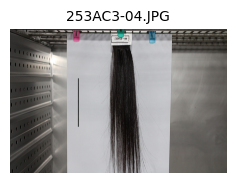

In [6]:
exibir_imagens_em_grade(imagens, nomes)

In [115]:
def detectar_mecha_e_calcular_largura(imagem, comprimento_linha_cm=10.0):
    hsv = cv2.cvtColor(imagem, cv2.COLOR_BGR2HSV)
    intervalos = {
        "loiro": (np.array([20, 0, 125]), np.array([40, 255, 230])),
        "castanho": (np.array([0, 0, 0]), np.array([255, 255, 80])),
        "ruivo": (np.array([0, 50, 50]), np.array([10, 255, 255])),
    }
    mask = sum(cv2.inRange(hsv, *intervalo) for intervalo in intervalos.values())
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contours = [contorno for contorno in contours if cv2.contourArea(contorno) >= 100]
    if not contours:
        print("Nenhum contorno encontrado!")
        return imagem, None, 0, 0, 0

    maior_contorno = max(contours, key=cv2.contourArea)
    imagem_com_contorno = imagem.copy()
    cv2.drawContours(imagem_com_contorno, [maior_contorno], -1, (0, 255, 0), 2)

    # Máscara da mecha
    mask_mecha = np.zeros_like(mask)
    cv2.drawContours(mask_mecha, [maior_contorno], -1, 255, -1)

    # Largura da mecha em cada linha
    larguras = []
    for y in range(mask_mecha.shape[0]):
        linha = mask_mecha[y, :]
        indices = np.where(linha > 0)[0]
        if len(indices) > 1:
            largura = indices[-1] - indices[0]
            larguras.append(largura)
    if len(larguras) == 0:
        largura_media = 0
        desvio_padrao = 0
    else:
        largura_media = np.mean(larguras)
        desvio_padrao = np.std(larguras)

    # --- DETECTAR LINHA PRETA DE REFERÊNCIA ---
    mask_black = cv2.inRange(hsv, np.array([0, 0, 0]), np.array([180, 255, 50]))
    contours_black, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours_black:
        print("Linha preta não encontrada!")
        return imagem_com_contorno, maior_contorno, 0, 0, 0

    linha_preta = max(contours_black, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(linha_preta)
    comprimento_linha_pixels = max(w, h)  # Pega o maior lado (horizontal ou vertical)

    # --- CONVERSÃO PARA CENTÍMETROS ---
    fator = comprimento_linha_cm / comprimento_linha_pixels if comprimento_linha_pixels > 0 else 0
    largura_media_cm = largura_media * fator
    desvio_padrao_cm = desvio_padrao * fator

    return imagem_com_contorno, maior_contorno, largura_media_cm, desvio_padrao_cm, fator


In [116]:
def processar_e_exibir_imagens(imagens, nomes, max_colunas=4):
    imagens_com_contorno = []
    titulos = []
    resultados = []

    for i, img in enumerate(imagens):
        imagem_com_contorno, maior_contorno, largura_media, desvio_padrao, _ = detectar_mecha_e_calcular_largura(img)
        imagens_com_contorno.append(imagem_com_contorno)
        titulos.append(f"{nomes[i]}\nLargura média: {largura_media:.2f}\nDesvio: {desvio_padrao:.2f}")
        resultados.append({
            "Nome": nomes[i],
            "Largura Média": round(largura_media, 2),
            "Desvio Padrão": round(desvio_padrao, 2),
        })

    df = pd.DataFrame(resultados)
    df.to_excel("Resultado_Largura_Mecha.xlsx", index=False)
    print("Resultados salvos no arquivo: 'Resultado_Largura_Mecha.xlsx'")
    exibir_imagens_em_grade(imagens_com_contorno, titulos, max_colunas)

Resultados salvos no arquivo: 'Resultado_Largura_Mecha.xlsx'


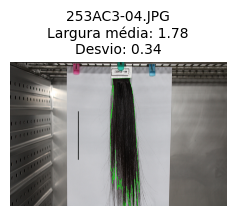

In [117]:
processar_e_exibir_imagens(imagens, nomes)